- Họ và tên: Trần Nhật Trường
- MSSV: 24120486


### Import các thư viện


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')


### Lấy data test và train

In [2]:
train_df = pd.read_csv('spaceship-titanic/train.csv')
test_df = pd.read_csv('spaceship-titanic/test.csv')

print(train_df.head())
print(test_df.head())
print(train_df.shape)
print(test_df.shape)


  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  
  

### Xem thông tin tổng quan


In [3]:
print(train_df.info())
print('\nSố lượng nhãn:')
print(train_df['Transported'].value_counts())
print('\nTỷ lệ nhãn:')
print(train_df['Transported'].value_counts(normalize=True))


<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
None

Số lượng nhãn:
Transported
True     4378
False    4315
Name: count, dtype: int64

Tỷ lệ nhãn:
Transported
True     0.503624
False    0.4963

### EDA

tách `Cabin` ra một dataframe phụ để xem thống kê, nhưng vẫn giữ nguyên dữ liệu gốc ở `train_df`.


In [4]:
train_eda = train_df.copy()
train_eda[['Cabin_deck', 'Cabin_num', 'Cabin_side']] = train_eda['Cabin'].str.split('/', expand=True)
train_eda['Cabin_num'] = train_eda['Cabin_num'].astype(float)

print(train_eda.describe())


               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck    Cabin_num  
count   8505.000000  8494.000000  
mean     304.854791   600.367671  
std     1145.717189   511.867226  
min        0.000000     0.000000  
25%        0.000000   167.250000  
50%        0.000000   427.000000  
75%       46.000000   999.000000  
max    24133.0000

CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
Spa             2.105142
FoodCourt       2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
PassengerId     0.000000
Transported     0.000000
dtype: float64


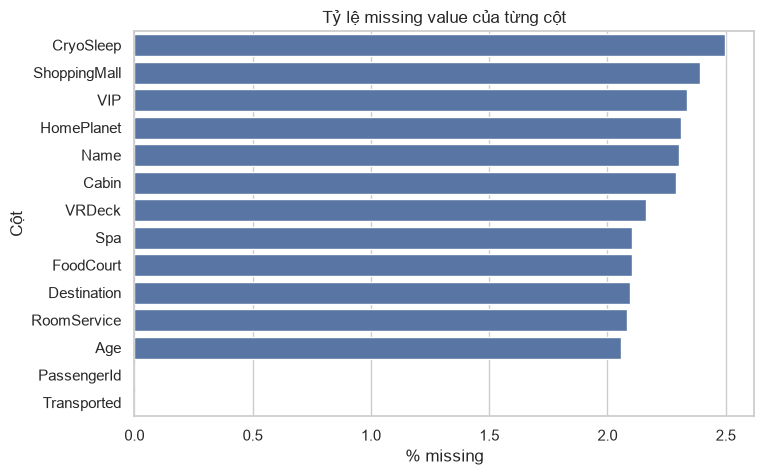

In [5]:
missing_percent = train_df.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_percent.sort_values(ascending=False).values, y=missing_percent.sort_values(ascending=False).index)
plt.title('Tỷ lệ missing value của từng cột')
plt.xlabel('% missing')
plt.ylabel('Cột')
plt.show()


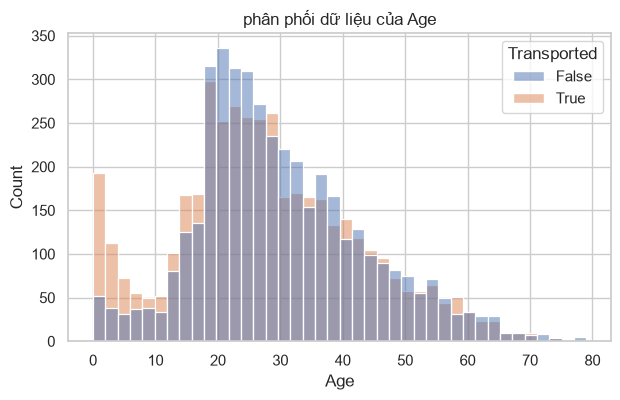

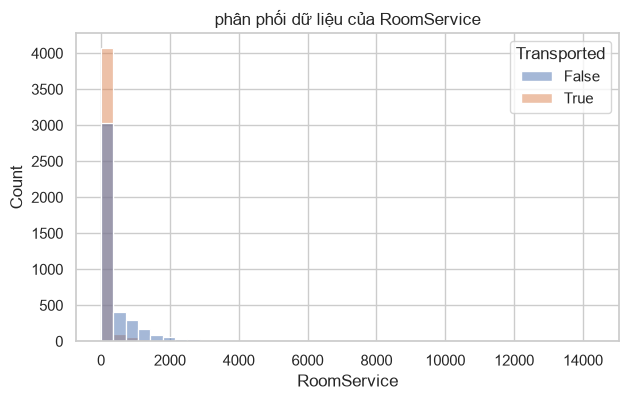

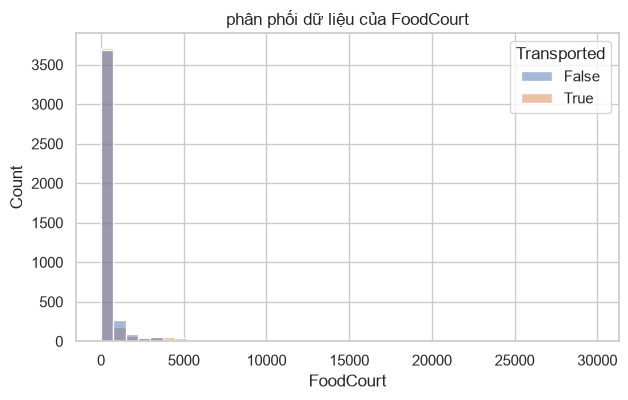

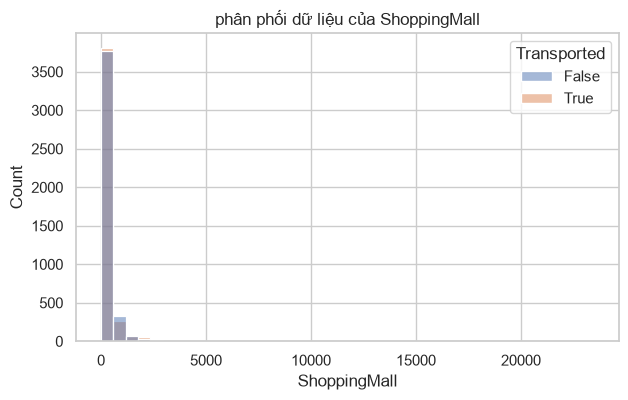

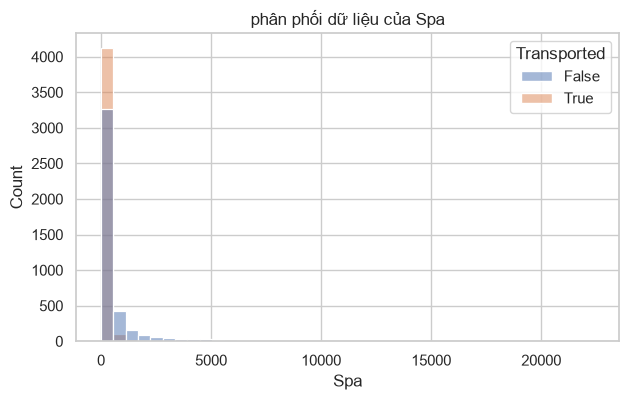

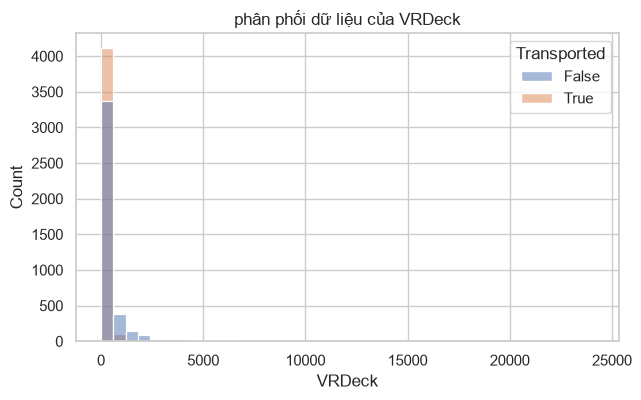

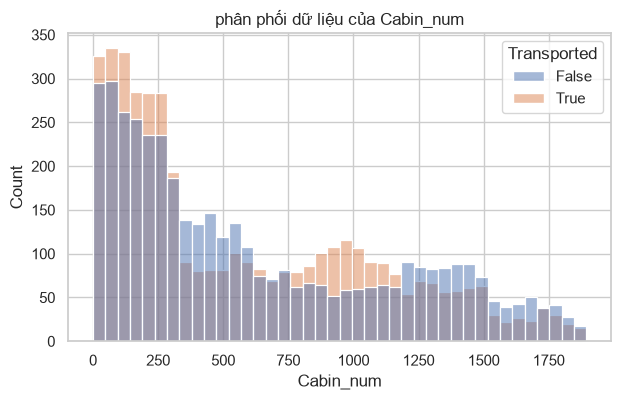

In [6]:
df_num = train_eda.select_dtypes(include=['number'])
features = df_num.columns

for feature in features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=train_eda, x=feature, hue='Transported', bins=40)
    plt.title(f'phân phối dữ liệu của {feature}')
    plt.show()


In [7]:
df_cat = train_eda.select_dtypes(include=['object', 'category', 'bool'])
df_cat = df_cat.drop(['Name', 'PassengerId', 'Cabin'], axis=1, errors='ignore')

for col in df_cat:
    print(f"\n===== TỶ LỆ PHÂN BỐ CỦA CỘT: {col} =====")
    print(df_cat[col].value_counts(normalize=True, dropna=False) * 100)



===== TỶ LỆ PHÂN BỐ CỦA CỘT: HomePlanet =====
HomePlanet
Earth     52.939146
Europa    24.513977
Mars      20.234672
NaN        2.312205
Name: proportion, dtype: float64

===== TỶ LỆ PHÂN BỐ CỦA CỘT: CryoSleep =====
CryoSleep
False    62.567583
True     34.936156
NaN       2.496261
Name: proportion, dtype: float64

===== TỶ LỆ PHÂN BỐ CỦA CỘT: Destination =====
Destination
TRAPPIST-1e      68.043253
55 Cancri e      20.706315
PSO J318.5-22     9.156793
NaN               2.093639
Name: proportion, dtype: float64

===== TỶ LỆ PHÂN BỐ CỦA CỘT: VIP =====
VIP
False    95.375590
NaN       2.335212
True      2.289198
Name: proportion, dtype: float64

===== TỶ LỆ PHÂN BỐ CỦA CỘT: Transported =====
Transported
True     50.362361
False    49.637639
Name: proportion, dtype: float64

===== TỶ LỆ PHÂN BỐ CỦA CỘT: Cabin_deck =====
Cabin_deck
F      32.140803
G      29.437478
E      10.077074
B       8.961233
C       8.593121
D       5.498677
A       2.944898
NaN     2.289198
T       0.057518
Name: 

In [8]:
cat_view_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_deck', 'Cabin_side']

for col in cat_view_cols:
    print(f"\n===== TỶ LỆ TRANSPORTED THEO {col} =====")
    print(train_eda.groupby(col, dropna=False)['Transported'].mean().sort_values(ascending=False))



===== TỶ LỆ TRANSPORTED THEO HomePlanet =====
HomePlanet
Europa    0.658846
Mars      0.523024
NaN       0.512438
Earth     0.423946
Name: Transported, dtype: float64

===== TỶ LỆ TRANSPORTED THEO CryoSleep =====
CryoSleep
True     0.817583
NaN      0.488479
False    0.328921
Name: Transported, dtype: float64

===== TỶ LỆ TRANSPORTED THEO Destination =====
Destination
55 Cancri e      0.610000
NaN              0.505495
PSO J318.5-22    0.503769
TRAPPIST-1e      0.471175
Name: Transported, dtype: float64

===== TỶ LỆ TRANSPORTED THEO VIP =====
VIP
NaN      0.512315
False    0.506332
True     0.381910
Name: Transported, dtype: float64

===== TỶ LỆ TRANSPORTED THEO Cabin_deck =====
Cabin_deck
B      0.734275
C      0.680054
G      0.516217
NaN    0.502513
A      0.496094
F      0.439871
D      0.433054
E      0.357306
T      0.200000
Name: Transported, dtype: float64

===== TỶ LỆ TRANSPORTED THEO Cabin_side =====
Cabin_side
S      0.555037
NaN    0.502513
P      0.451260
Name: Transporte

### Nhận xét sau EDA

- Dữ liệu train có 8693 dòng, test có 4277 dòng.
- Nhãn Transported khá cân bằng nên accuracy là metric phù hợp để benchmark.
- Missing value mỗi cột không quá nhiều nên có thể điền bằng median/mode.
- CryoSleep, Cabin, HomePlanet, Destination và các cột chi tiêu có khả năng liên quan đến nhãn.


### Tạo thêm đặc trưng mới

gộp train và test để tạo feature cùng một cách và để khi one-hot encoding thì hai tập có cùng bộ cột. Việc gộp này không dùng nhãn của test.


In [9]:
y = train_df['Transported'].astype(int)
PassengerId_test = test_df['PassengerId']

all_data = pd.concat([train_df.drop('Transported', axis=1), test_df], axis=0).reset_index(drop=True)
print(all_data.shape)


(12970, 13)


In [10]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

data = all_data.copy()

# Tách PassengerId thành nhóm và số thứ tự trong nhóm
data[['GroupId', 'GroupNumber']] = data['PassengerId'].str.split('_', expand=True)
data['GroupNumber'] = data['GroupNumber'].astype(float)
data['GroupSize'] = data.groupby('GroupId')['PassengerId'].transform('count')
data['IsAlone'] = (data['GroupSize'] == 1).astype(int)

# Tách Cabin thành deck, số cabin và side
data[['Cabin_deck', 'Cabin_num', 'Cabin_side']] = data['Cabin'].str.split('/', expand=True)
data['Cabin_num'] = data['Cabin_num'].astype(float)
data['Cabin_region'] = pd.cut(
    data['Cabin_num'],
    bins=[-1, 300, 600, 900, 1200, 1500, 1900],
    labels=['R1', 'R2', 'R3', 'R4', 'R5', 'R6']
)

# Tạo đặc trưng chi tiêu
data['TotalSpend'] = data[spend_cols].fillna(0).sum(axis=1)
data['LogTotalSpend'] = np.log1p(data['TotalSpend'])
data['NoSpend'] = (data['TotalSpend'] == 0).astype(int)
data['LuxurySpend'] = data[['Spa', 'VRDeck']].fillna(0).sum(axis=1)
data['ServiceSpend'] = data[['RoomService', 'FoodCourt', 'ShoppingMall']].fillna(0).sum(axis=1)
data['SpendMissingCount'] = data[spend_cols].isnull().sum(axis=1)

# Tạo nhóm tuổi
data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=[-1, 12, 18, 30, 45, 60, 100],
    labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior', 'Elder']
)

# Tách họ để ước lượng kích thước gia đình
data['Surname'] = data['Name'].fillna('Unknown').astype(str).str.split().str[-1]
data['FamilySize'] = data.groupby('Surname')['PassengerId'].transform('count')

print(data.head())
print(data.shape)


  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

  GroupId  GroupNumber  GroupSize  IsAlone Cabin_deck  Cabin_num Cabin_side  \
0    0001          1.0   

### Xem nhanh feature mới


In [11]:
train_feature_view = data.iloc[:len(train_df)].copy()
train_feature_view['Transported'] = y.values

new_cat_cols = ['Cabin_deck', 'Cabin_side', 'Cabin_region', 'AgeGroup', 'NoSpend', 'IsAlone']
for col in new_cat_cols:
    print(f"\n===== TỶ LỆ TRANSPORTED THEO {col} =====")
    print(train_feature_view.groupby(col, dropna=False)['Transported'].mean().sort_values(ascending=False))



===== TỶ LỆ TRANSPORTED THEO Cabin_deck =====
Cabin_deck
B      0.734275
C      0.680054
G      0.516217
NaN    0.502513
A      0.496094
F      0.439871
D      0.433054
E      0.357306
T      0.200000
Name: Transported, dtype: float64

===== TỶ LỆ TRANSPORTED THEO Cabin_side =====
Cabin_side
S      0.555037
NaN    0.502513
P      0.451260
Name: Transported, dtype: float64

===== TỶ LỆ TRANSPORTED THEO Cabin_region =====
Cabin_region
R4     0.604440
R3     0.543033
R1     0.538526
NaN    0.502513
R5     0.419424
R6     0.415270
R2     0.411725
Name: Transported, dtype: float64

===== TỶ LỆ TRANSPORTED THEO AgeGroup =====
AgeGroup
Child         0.699752
Teen          0.537299
NaN           0.502793
Senior        0.491944
Adult         0.476549
Elder         0.472727
YoungAdult    0.468190
Name: Transported, dtype: float64

===== TỶ LỆ TRANSPORTED THEO NoSpend =====
NoSpend
1    0.786477
0    0.298611
Name: Transported, dtype: float64

===== TỶ LỆ TRANSPORTED THEO IsAlone =====
IsAlone
0

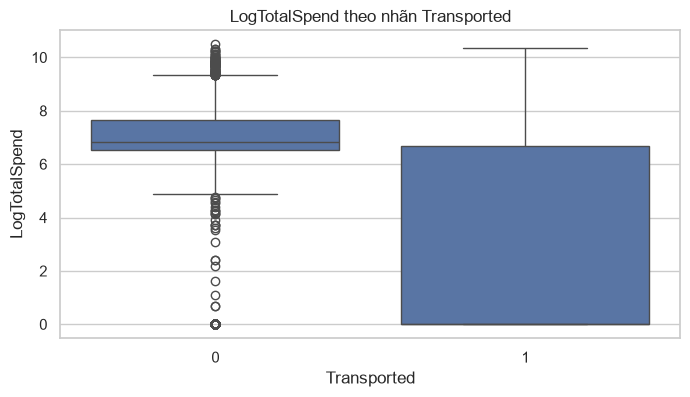

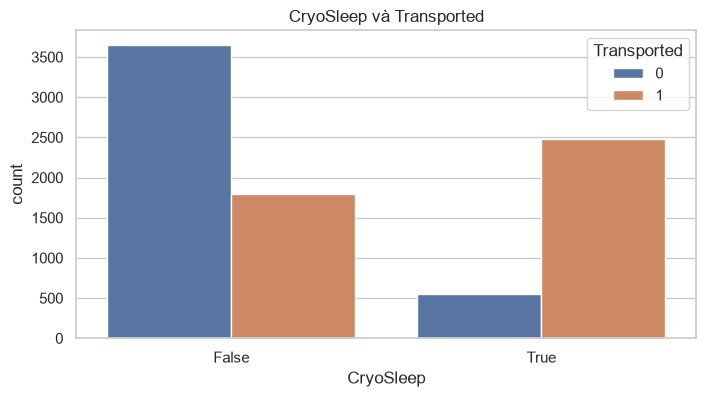

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_feature_view, x='Transported', y='LogTotalSpend')
plt.title('LogTotalSpend theo nhãn Transported')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=train_feature_view, x='CryoSleep', hue='Transported')
plt.title('CryoSleep và Transported')
plt.show()


### Chuẩn bị dữ liệu cho mô hình

bỏ các cột định danh hoặc quá nhiều giá trị khác nhau, sau đó tách lại thành train và test. Missing value sẽ được điền dựa trên tập train để cách xử lý hợp lý hơn.


In [13]:
model_data = data.drop(['PassengerId', 'Cabin', 'Name', 'GroupId', 'Surname'], axis=1)

train_model = model_data.iloc[:len(train_df)].copy()
test_model = model_data.iloc[len(train_df):].copy()

num_cols = train_model.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train_model.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Các cột số:')
print(num_cols)
print('\nCác cột phân loại:')
print(cat_cols)
print(train_model.shape)
print(test_model.shape)


Các cột số:
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupNumber', 'GroupSize', 'IsAlone', 'Cabin_num', 'TotalSpend', 'LogTotalSpend', 'NoSpend', 'LuxurySpend', 'ServiceSpend', 'SpendMissingCount', 'FamilySize']

Các cột phân loại:
['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_deck', 'Cabin_side', 'Cabin_region', 'AgeGroup']
(8693, 25)
(4277, 25)


### Chia tập train và validation


In [14]:
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    train_model, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train_raw.shape)
print(X_valid_raw.shape)
print(y_train.value_counts(normalize=True))
print(y_valid.value_counts(normalize=True))


(6954, 25)
(1739, 25)
Transported
1    0.503595
0    0.496405
Name: proportion, dtype: float64
Transported
1    0.503738
0    0.496262
Name: proportion, dtype: float64


### Xử lý missing value và encoding

- Cột số: điền missing bằng median của tập train.
- Cột categorical: điền missing bằng mode của tập train.
- Sau đó dùng pd.get_dummies để one-hot encoding và căn lại cột giữa train, validation, test.


In [15]:
num_median = X_train_raw[num_cols].median()
cat_mode = X_train_raw[cat_cols].mode().iloc[0]


def fill_missing(df):
    df = df.copy()
    for col in num_cols:
        df[col] = df[col].fillna(num_median[col])
    for col in cat_cols:
        df[col] = df[col].fillna(cat_mode[col])
    return df


X_train_fill = fill_missing(X_train_raw)
X_valid_fill = fill_missing(X_valid_raw)
X_test_fill = fill_missing(test_model)

all_encode = pd.concat([X_train_fill, X_valid_fill, X_test_fill], axis=0)
all_encode = pd.get_dummies(all_encode, columns=cat_cols, drop_first=False)

X_train = all_encode.iloc[:len(X_train_fill)].copy()
X_valid = all_encode.iloc[len(X_train_fill):len(X_train_fill) + len(X_valid_fill)].copy()
X_test = all_encode.iloc[len(X_train_fill) + len(X_valid_fill):].copy()

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)
print(X_train.isnull().sum().sum(), X_valid.isnull().sum().sum(), X_test.isnull().sum().sum())


(6954, 49)
(1739, 49)
(4277, 49)
0 0 0


### Tạo dữ liệu full train cho Cross Validation và submit

Ở bước train cuối, fit lại missing value trên toàn bộ train rồi encode train và test cùng nhau để hai tập chắc chắn có cùng cột.


In [16]:
full_num_median = train_model[num_cols].median()
full_cat_mode = train_model[cat_cols].mode().iloc[0]


def fill_missing_full(df):
    df = df.copy()
    for col in num_cols:
        df[col] = df[col].fillna(full_num_median[col])
    for col in cat_cols:
        df[col] = df[col].fillna(full_cat_mode[col])
    return df


train_full_fill = fill_missing_full(train_model)
test_full_fill = fill_missing_full(test_model)

full_encode = pd.concat([train_full_fill, test_full_fill], axis=0)
full_encode = pd.get_dummies(full_encode, columns=cat_cols, drop_first=False)

X_full = full_encode.iloc[:len(train_df)].copy()
X_test_full = full_encode.iloc[len(train_df):].copy()

print(X_full.shape)
print(X_test_full.shape)


(8693, 49)
(4277, 49)


### Huấn luyện thử các mô hình yêu cầu

Theo yêu cầu, phần mô hình chỉ dùng 4 mô hình:

- DecisionTreeClassifier: cây quyết định đơn lẻ để làm baseline.
- RandomForestClassifier: ensemble theo hướng bagging nhiều cây.
- BaggingClassifier với base model là Decision Tree.
- XGBClassifier: boosting bằng XGBoost.


In [17]:
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=8,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=450,
    max_depth=11,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=8, min_samples_leaf=8, random_state=42),
    n_estimators=120,
    max_samples=0.85,
    max_features=0.85,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=350,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

models = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Bagging Tree': bagging_model,
    'XGBoost': xgb_model,
}

print(list(models.keys()))


['Decision Tree', 'Random Forest', 'Bagging Tree', 'XGBoost']


### Đánh giá nhanh trên validation set


In [18]:
valid_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    acc = accuracy_score(y_valid, y_pred)
    valid_results.append([name, acc])
    print(f'{name}: {acc:.4f}')

valid_results = pd.DataFrame(valid_results, columns=['Model', 'Validation Accuracy'])
valid_results = valid_results.sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)
print(valid_results)


Decision Tree: 0.7838
Random Forest: 0.8005
Bagging Tree: 0.8068
XGBoost: 0.8085
           Model  Validation Accuracy
0        XGBoost             0.808511
1   Bagging Tree             0.806786
2  Random Forest             0.800460
3  Decision Tree             0.783784


### Đánh giá bằng Cross Validation

Validation set chỉ là một lần chia dữ liệu nên kết quả có thể phụ thuộc cách chia. Vì vậy dùng thêm Stratified K-Fold Cross Validation để benchmark công bằng hơn.


In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_full, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results.append([name, scores.mean(), scores.std()])
    print(f'{name}: {scores.mean():.4f} +/- {scores.std():.4f}')

cv_results = pd.DataFrame(cv_results, columns=['Model', 'CV Accuracy Mean', 'CV Accuracy Std'])
cv_results = cv_results.sort_values('CV Accuracy Mean', ascending=False).reset_index(drop=True)
print(cv_results)


Decision Tree: 0.7860 +/- 0.0111
Random Forest: 0.8046 +/- 0.0097
Bagging Tree: 0.8042 +/- 0.0095
XGBoost: 0.8121 +/- 0.0062
           Model  CV Accuracy Mean  CV Accuracy Std
0        XGBoost          0.812148         0.006199
1  Random Forest          0.804554         0.009710
2   Bagging Tree          0.804210         0.009462
3  Decision Tree          0.786035         0.011128


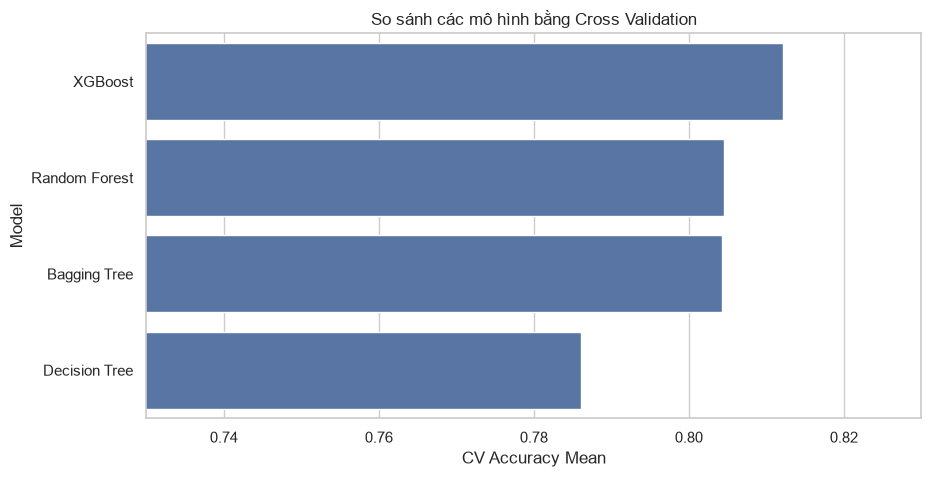

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(data=cv_results, x='CV Accuracy Mean', y='Model')
plt.title('So sánh các mô hình bằng Cross Validation')
plt.xlim(0.73, 0.83)
plt.show()


### Tuning mô hình tốt

Sau khi benchmark, tuning thêm XGBClassifier vì đây là mô hình boosting mạnh, thường cho kết quả tốt với dữ liệu dạng bảng như Spaceship Titanic.


In [21]:
tune_model_name = 'XGBoost'
tune_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

params = {
    'n_estimators': [250, 350, 450, 600],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.025, 0.04, 0.06, 0.08],
    'subsample': [0.75, 0.85, 0.95],
    'colsample_bytree': [0.75, 0.85, 0.95],
    'reg_lambda': [0.5, 1.0, 2.0],
    'min_child_weight': [1, 3, 5],
}

search = RandomizedSearchCV(
    tune_model,
    param_distributions=params,
    n_iter=20,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1
)

search.fit(X_full, y)
print('Tuning model:', tune_model_name)
print('Best score:', search.best_score_)
print('Best params:', search.best_params_)


Tuning model: XGBoost
Best score: 0.8105374073542043
Best params: {'subsample': 0.85, 'reg_lambda': 1.0, 'n_estimators': 450, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.025, 'colsample_bytree': 0.75}


### Kiểm tra mô hình tốt nhất trên validation


Accuracy: 0.8113858539390454
ROC-AUC: 0.9103623337936582
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       863
           1       0.81      0.82      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



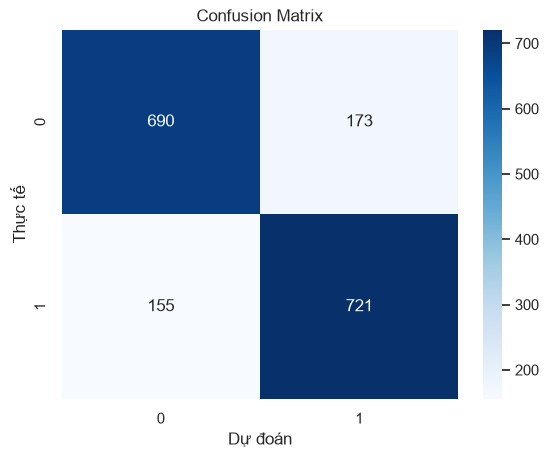

In [22]:
best_model = search.best_estimator_
best_model.fit(X_train, y_train)

pred_valid = best_model.predict(X_valid)
proba_valid = best_model.predict_proba(X_valid)[:, 1]

print('Accuracy:', accuracy_score(y_valid, pred_valid))
print('ROC-AUC:', roc_auc_score(y_valid, proba_valid))
print(classification_report(y_valid, pred_valid))

cm = confusion_matrix(y_valid, pred_valid)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()


### Huấn luyện trên toàn bộ train và tạo file submit Kaggle

Sau khi chọn mô hình tốt, em train lại trên toàn bộ tập train rồi dự đoán cho tập test.


In [23]:
final_model = search.best_estimator_
final_model.fit(X_full, y)

test_pred = final_model.predict(X_test_full).astype(bool)

sample_submission = pd.read_csv('spaceship-titanic/sample_submission.csv')
submission = sample_submission.copy()
submission['Transported'] = test_pred

submission.to_csv('submission_24120486.csv', index=False)
print(submission.head())
print(submission.shape)
print(submission['Transported'].value_counts(normalize=True))


  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
(4277, 2)
Transported
True     0.517653
False    0.482347
Name: proportion, dtype: float64


#### Kaggle public score: 0.80547
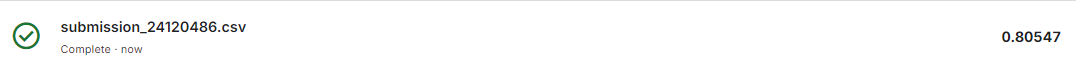
